In [1]:
pip install pandas numpy matplotlib seaborn scipy


Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
print("Pandas installed:", pd.__version__)

Pandas installed: 3.0.2


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt   
import seaborn as sns
import warnings
import sqlite3
from scipy.stats import ttest_ind
import scipy.stats as stats

warnings.filterwarnings('ignore')   

In [4]:
#loading  database connection
conn = sqlite3.connect('inventory.db')

#fetching vendor summary data
df = pd.read_sql_query("select * from vendor_sales_summary",conn)
df.head()

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesToPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,142049.0,5101919.51,672819.31,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,160247.0,4819073.49,561512.37,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,187140.0,4538120.60,461140.15,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,200412.0,4475972.88,420050.01,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,135838.0,4223107.62,545778.28,249587.83,257032.07,1199901.61,28.412764,0.983556,1.396897


In [5]:
#summary Staticstic 
df.describe

<bound method NDFrame.describe of        VendorNumber                VendorName  Brand  \
0              1128         BROWN-FORMAN CORP   1233   
1              4425     MARTIGNETTI COMPANIES   3405   
2             17035         PERNOD RICARD USA   8068   
3              3960  DIAGEO NORTH AMERICA INC   4261   
4              3960  DIAGEO NORTH AMERICA INC   3545   
...             ...                       ...    ...   
10687          9815            WINE GROUP INC   8527   
10688          8004            SAZERAC CO INC   5683   
10689          3924  HEAVEN HILL DISTILLERIES   9123   
10690          3960  DIAGEO NORTH AMERICA INC   6127   
10691          7245      PROXIMO SPIRITS INC.   3065   

                       Description  PurchasePrice  ActualPrice  Volume  \
0          Jack Daniels No 7 Black          26.27        36.99  1750.0   
1            Tito's Handmade Vodka          23.19        28.99  1750.0   
2                 Absolut 80 Proof          18.24        24.99  1750.0 

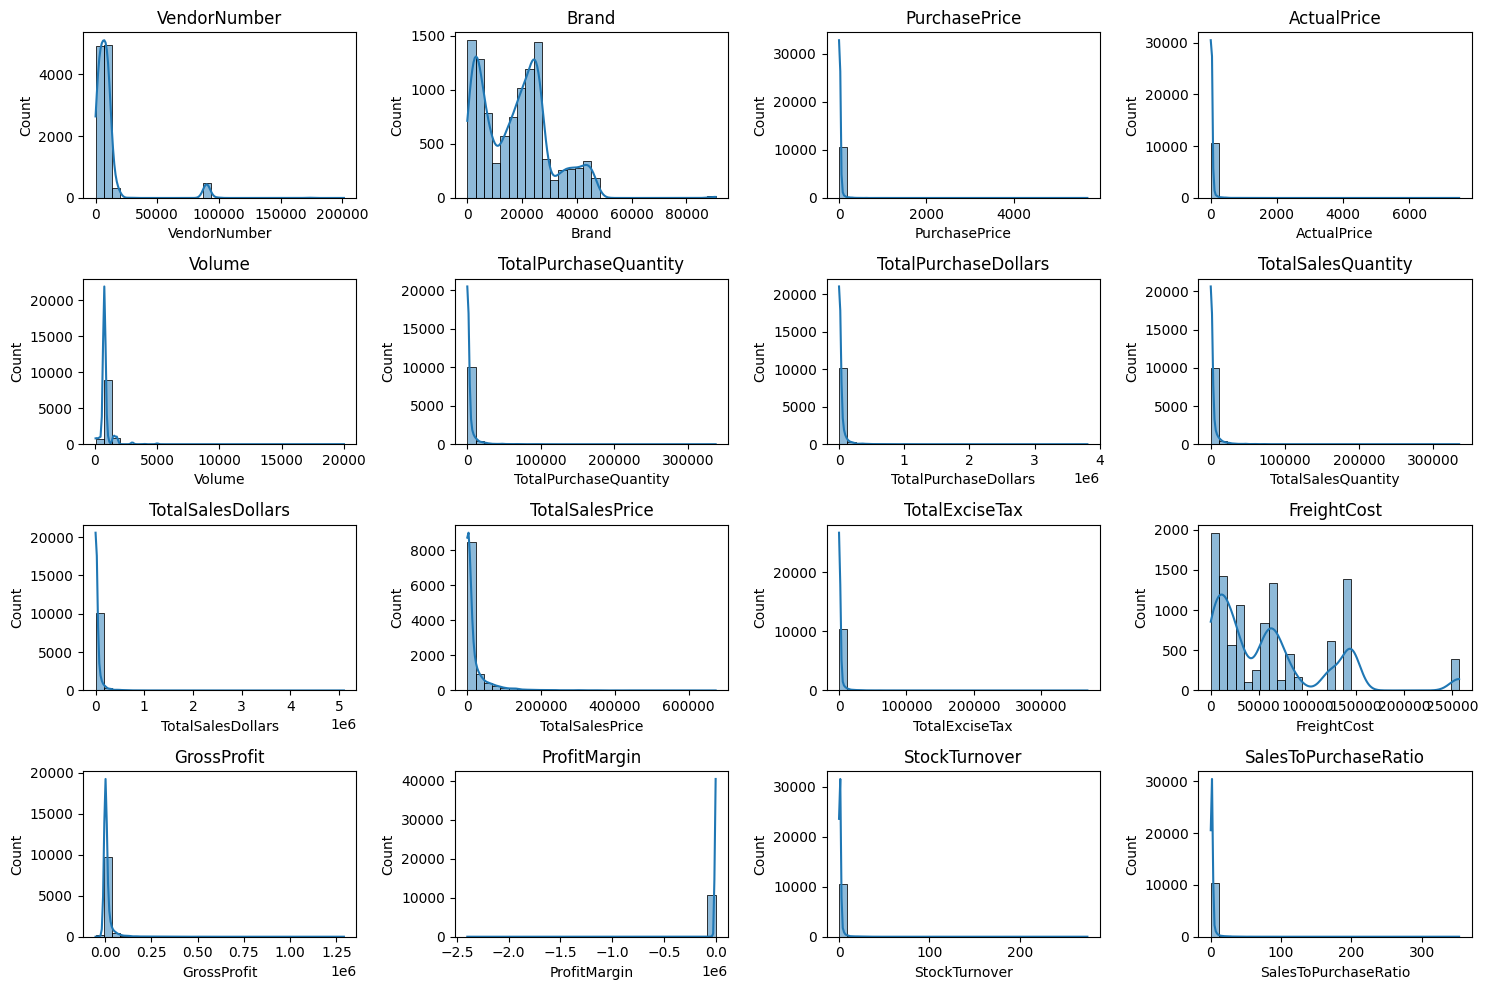

In [6]:
# Distribution plots for numerical columns
numerical_cols = df.select_dtypes(include=['number']).columns

plt.figure(figsize=(15, 10))  

for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i + 1) 
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(col)

plt.tight_layout()
plt.show()
           

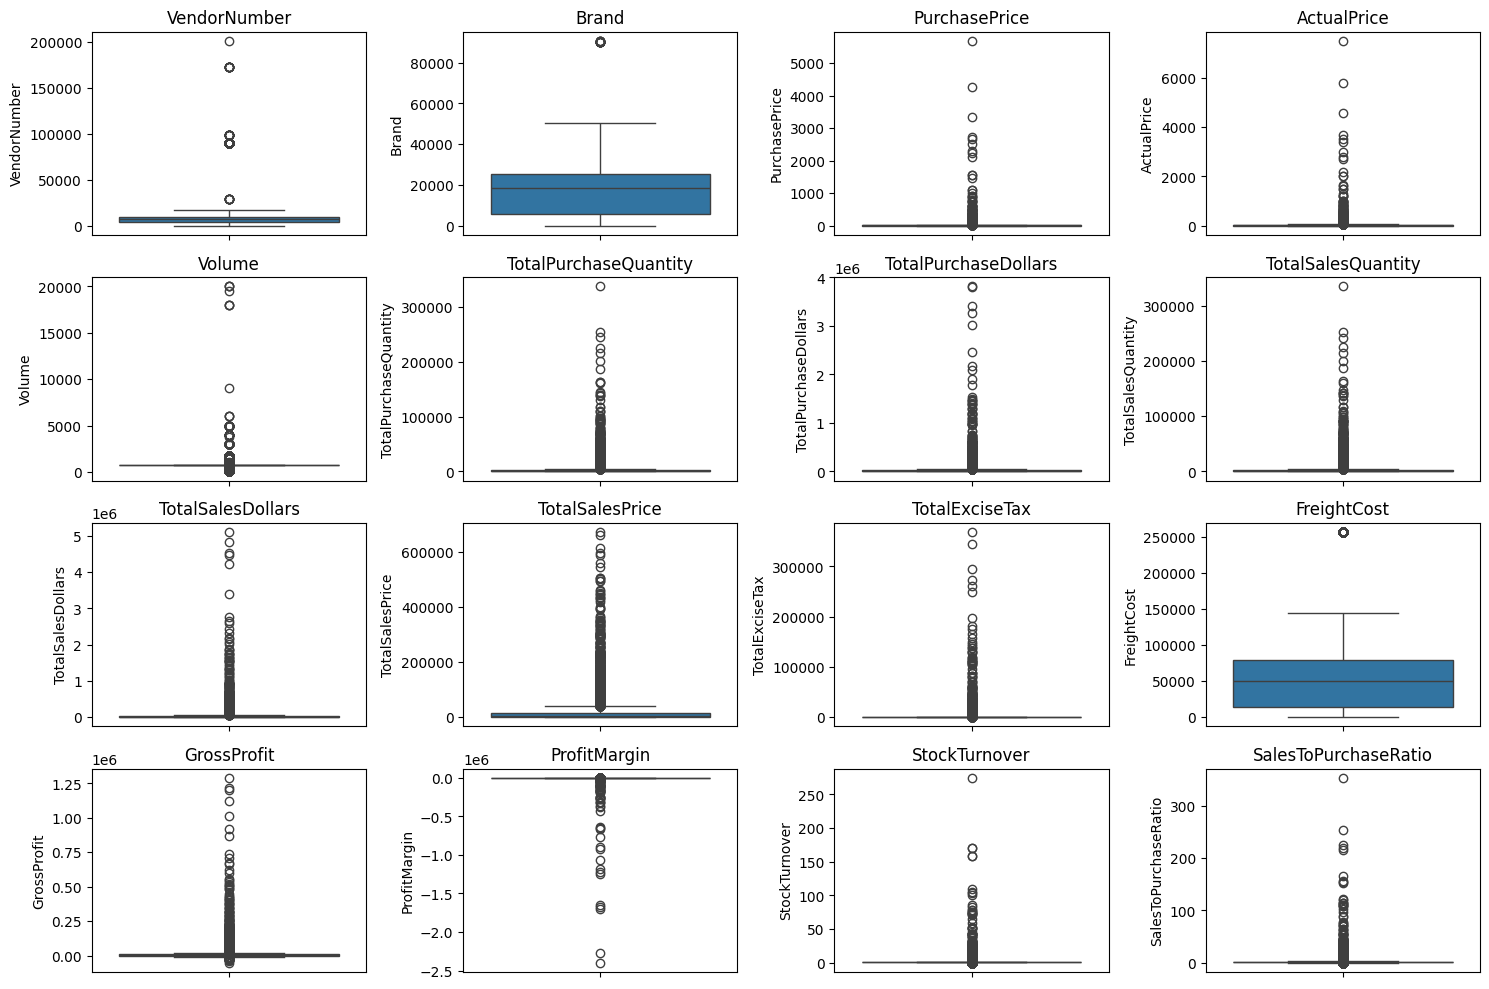

In [7]:
 # Outlier Detection with Boxplots
plt.figure(figsize=(15, 10))

for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i + 1)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

summary Statics insights:
Negative & Zero Values:
- Gross Profit: Minimum value is -52,002.78, indicating losses. Some products or transactions may be selling at a loss due to high costs or selling at discounts lower than the purchase price.
- Profit Margin: Has a minimum of -∞, which suggests cases where revenue is zero or even lower than costs.
- Total Sales Quantity & Sales Dollars: Minimum values are 0, meaning some products were purchased but never sold. These could be slow-moving or obsolete stock.
Outliers Indicated by High Standard Deviations:
- Purchase & Actual Prices: The max values (5,681.81 & 7,499.99) are significantly higher than the mean (24.39 & 35.64), indicating potential premium products.
- Freight Cost: Huge variation, from 0.09 to 257,032.07, suggests logistics inefficiencies or bulk shipments.
- Stock Turnover: Ranges from 0 to 274.5, implying some products sell extremely fast while others remain in stock indefinitely. Value more than 1 indicates that sold quantity for that product is higher than purchased quantity due to either sales being fulfilled from older stock


In [8]:
# let's filter the data by removing inconsistencies
df = pd.read_sql_query("""SELECT *
FROM vendor_sales_summary
WHERE GrossProfit > 0
AND ProfitMargin > 0
AND TotalSalesQuantity > 0""", conn)


In [9]:
df

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesToPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,142049.0,5101919.51,672819.31,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,160247.0,4819073.49,561512.37,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,187140.0,4538120.60,461140.15,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,200412.0,4475972.88,420050.01,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,135838.0,4223107.62,545778.28,249587.83,257032.07,1199901.61,28.412764,0.983556,1.396897
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8559,9815,WINE GROUP INC,8527,Concannon Glen Ellen Wh Zin,1.32,4.99,750.0,2,2.64,5.0,15.95,10.96,0.55,27100.41,13.31,83.448276,2.500000,6.041667
8560,8004,SAZERAC CO INC,5683,Dr McGillicuddy's Apple Pie,0.39,0.49,50.0,6,2.34,134.0,65.66,1.47,7.04,50293.62,63.32,96.436186,22.333333,28.059829
8561,3924,HEAVEN HILL DISTILLERIES,9123,Deep Eddy Vodka,0.74,0.99,50.0,2,1.48,2.0,1.98,0.99,0.10,14069.87,0.50,25.252525,1.000000,1.337838
8562,3960,DIAGEO NORTH AMERICA INC,6127,The Club Strawbry Margarita,1.47,1.99,200.0,1,1.47,72.0,143.28,77.61,15.12,257032.07,141.81,98.974037,72.000000,97.469388


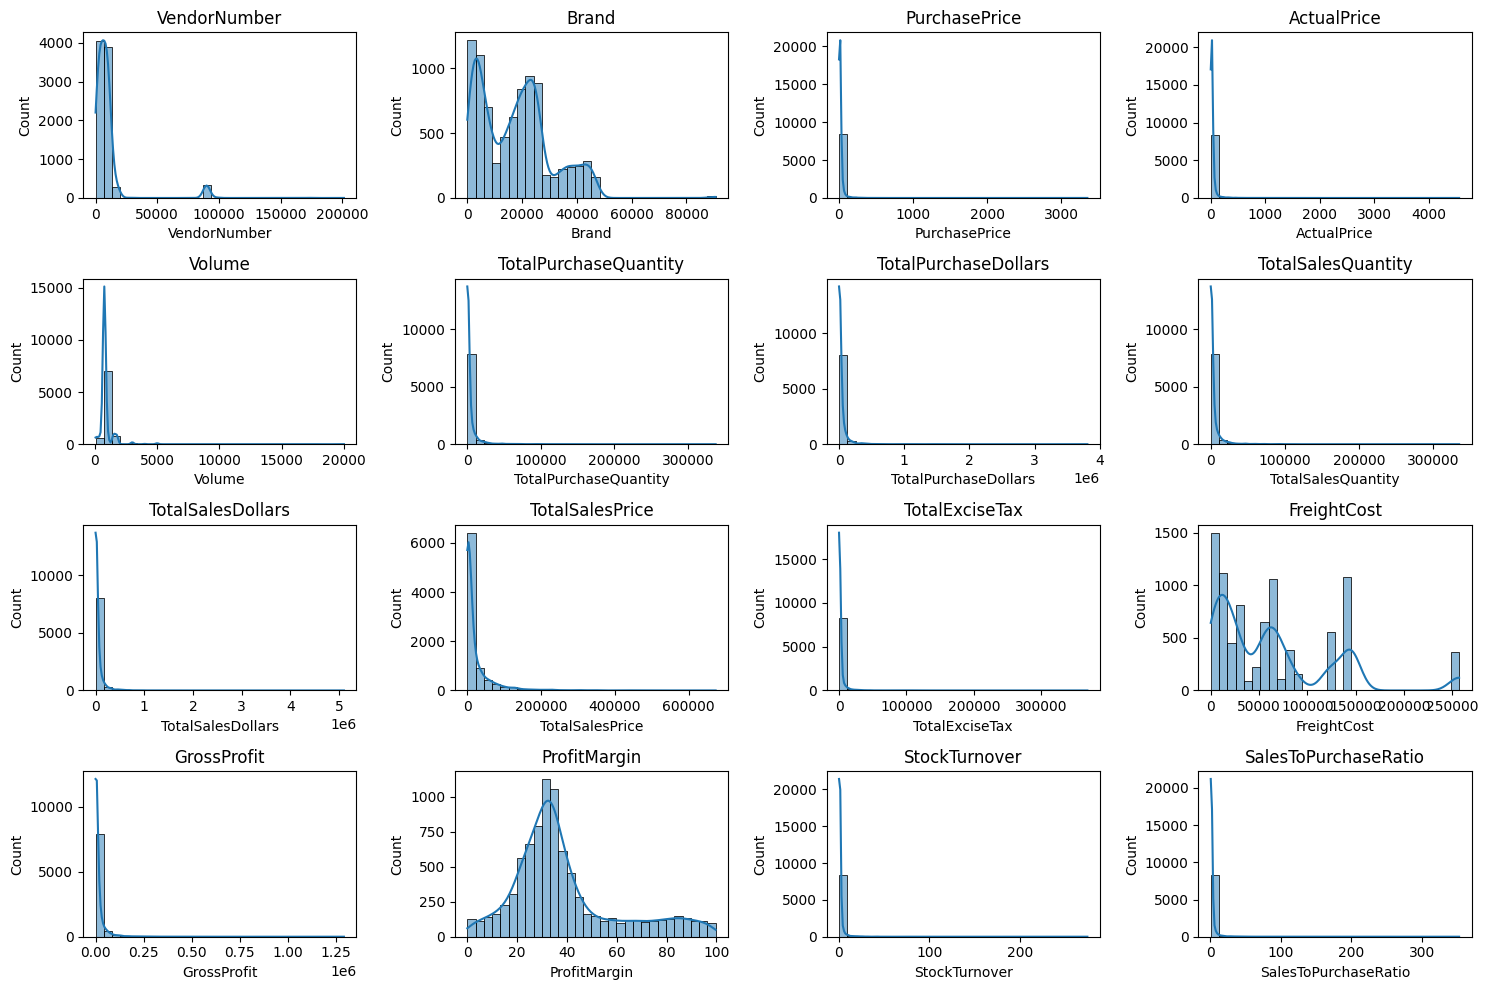

In [10]:
# Distribution plots for numerical columns
numerical_cols = df.select_dtypes(include=['number']).columns

plt.figure(figsize=(15, 10))  

for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i + 1) 
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(col)

plt.tight_layout()
plt.show()
           

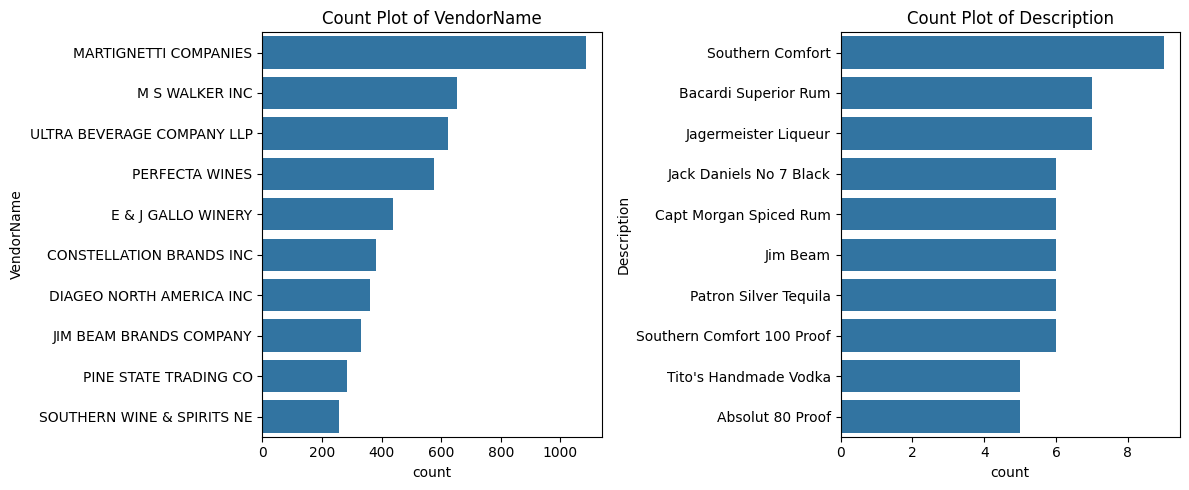

In [11]:
# Count Plots for Categorical Columns
categorical_cols = ["VendorName", "Description"]

plt.figure(figsize=(12, 5))
for i, col in enumerate(categorical_cols):
    plt.subplot(1, 2, i+1)
    sns.countplot(y=df[col], order=df[col].value_counts().index[:10])  # Top 10 categories
    plt.title(f"Count Plot of {col}")
plt.tight_layout()
plt.show()


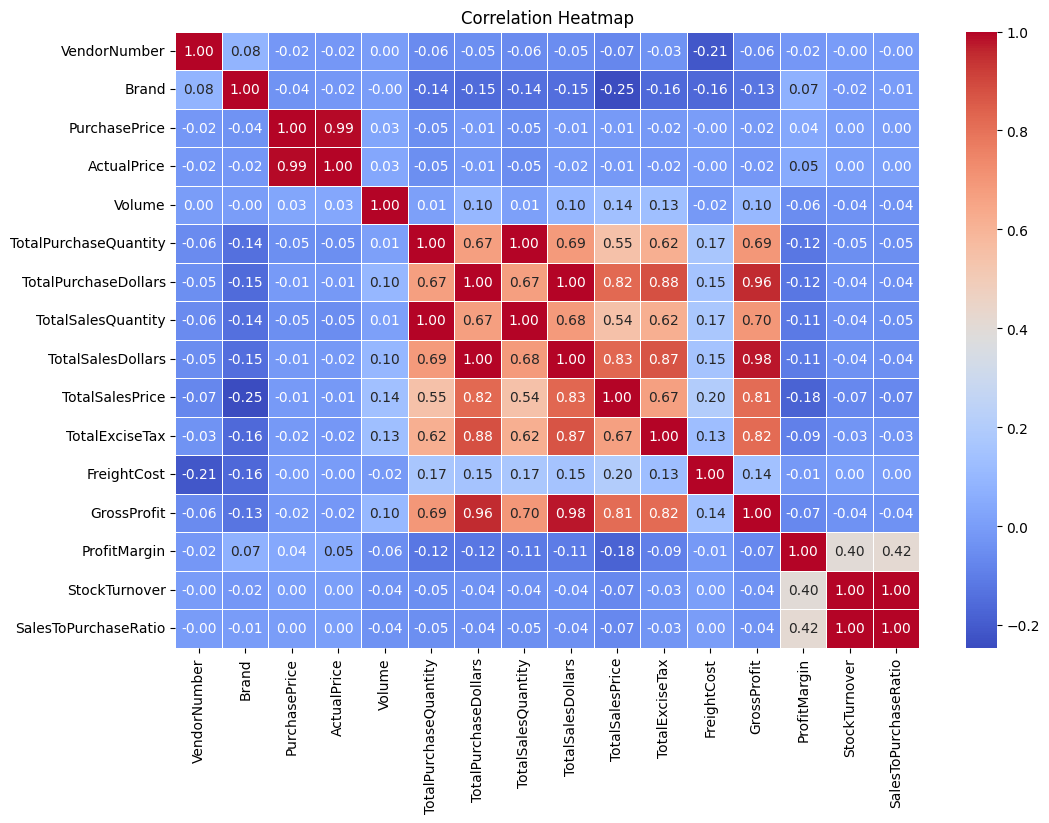

In [12]:
 #Correlation Heatmap
plt.figure(figsize=(12, 8))
correlation_matrix = df[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()


Correlation Insights ¶
- PurchasePrice has weak correlations with TotalSalesDollars (-0.012) and GrossProfit (-0.016), suggesting that price variations do not significantly impact sales revenue or profit.
- Strong correlation between TotalPurchaseQuantity and TotalSalesQuantity (0.999), confirming efficient inventory turnover.
- Negative correlation between ProfitMargin & TotalSalesPrice (-0.179) suggests that as sales price increases, margins decrease, possibly due to competitive pricing pressures.
- StockTurnover has weak negative correlations with both GrossProfit (-0.038) and ProfitMargin (-0.055), indicating that faster turnover does not necessarily result in higher profitability


data analysis
identify brands that needs promotional or pricing adjustments which exhibit lower sales performance but higher profit margins

In [13]:
df.groupby('Description').agg({
    'TotalSalesDollars': 'sum',
    'ProfitMargin': 'mean'}).reset_index()

,Description,TotalSalesDollars,ProfitMargin
0,(RI) 1,21519.09,18.060661
1,.nparalleled Svgn Blanc,1094.63,29.978166
2,10 Span Cab Svgn CC,2703.89,20.937612
3,10 Span Chard CC,3325.56,27.806445
4,10 Span Pnt Gris Monterey Cy,2082.22,32.226182
...,...,...,...
7702,Zorvino Vyds Sangiovese,10579.03,29.525675
7703,Zuccardi Q Malbec,1639.18,23.981503
7704,Zum Rsl,10857.34,32.675038
7705,Zwack Liqueur,227.88,16.653502


In [14]:
brand_performance = df.groupby('Brand').agg({
    'TotalSalesDollars': 'sum',
    'ProfitMargin': 'mean'
}).reset_index()


In [15]:
low_sales_threshold = brand_performance['TotalSalesDollars'].quantile(0.15)
high_margin_threshold = brand_performance['ProfitMargin'].quantile(0.85)


In [16]:
low_sales_threshold

np.float64(563.53)

In [17]:
high_margin_threshold

np.float64(63.40726764137595)

In [18]:
# Filter brands with low sales but high profit margins
target_brands = brand_performance[
    (brand_performance['TotalSalesDollars'] <= low_sales_threshold) &
    (brand_performance['ProfitMargin'] >= high_margin_threshold)
]

print("Brands with Low Sales but High Profit Margins:")
display(target_brands.sort_values('TotalSalesDollars'))

Brands with Low Sales but High Profit Margins:


,Brand,TotalSalesDollars,ProfitMargin
5493,22161,9.99,66.466466
4348,18073,11.58,65.975820
2868,8527,15.95,83.448276
965,2626,27.86,89.806174
2302,6064,27.96,82.153076
...,...,...,...
7632,36571,543.79,63.964030
117,369,545.58,64.373694
5735,23078,549.75,66.444748
4766,19591,558.87,69.434752


INFO:root:Loading data from database...
INFO:root:Cleaning data...
INFO:root:Creating visualization...


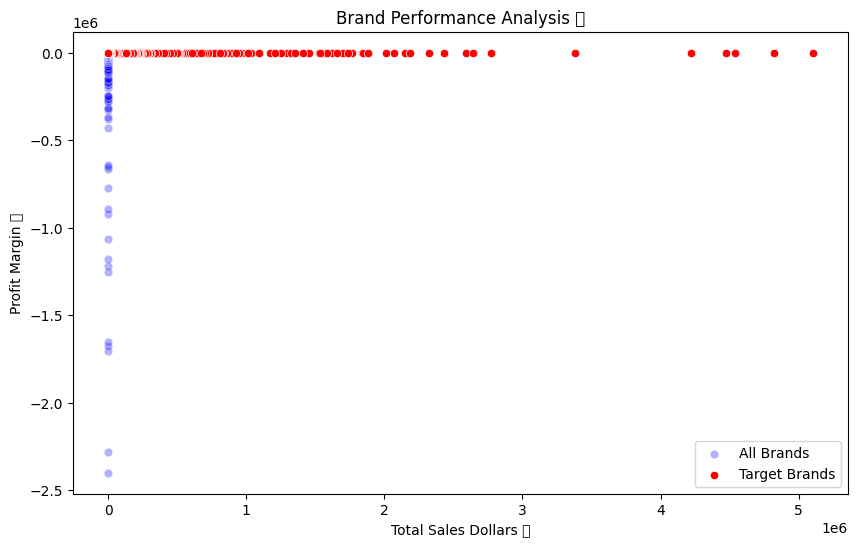

INFO:root:Completed Successfully ✅


In [19]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import logging

# Setup logging
logging.basicConfig(level=logging.INFO)

# 🔹 Step 1: Connect to database
conn = sqlite3.connect('inventory.db')

# 🔹 Step 2: Load data from table
logging.info("Loading data from database...")
query = "SELECT * FROM vendor_sales_summary"
brand_performance = pd.read_sql(query, conn)

# 🔹 Step 3: Basic data cleaning
logging.info("Cleaning data...")

# Remove null values
brand_performance = brand_performance.dropna()

# Convert ProfitMargin to numeric (if needed)
brand_performance['ProfitMargin'] = pd.to_numeric(
    brand_performance['ProfitMargin'], errors='coerce'
)

# Remove invalid rows
brand_performance = brand_performance.dropna(subset=['ProfitMargin'])

# 🔹 Step 4: Filter target brands
target_brands = brand_performance[
    brand_performance['ProfitMargin'] > 0.3
]

# 🔹 Step 5: Visualization
logging.info("Creating visualization...")

plt.figure(figsize=(10, 6))

# All brands
sns.scatterplot(
    data=brand_performance,
    x='TotalSalesDollars',
    y='ProfitMargin',
    color='blue',
    label='All Brands',
    alpha=0.3
)

# Target brands
sns.scatterplot(
    data=target_brands,
    x='TotalSalesDollars',
    y='ProfitMargin',
    color='red',
    label='Target Brands'
)

# Labels and title
plt.title("Brand Performance Analysis 📊")
plt.xlabel("Total Sales Dollars 💰")
plt.ylabel("Profit Margin 📈")
plt.legend()

plt.show()

# 🔹 Step 6: Close connection
conn.close()

logging.info("Completed Successfully ✅")

In [20]:
import pandas as pd

# Load data
df = pd.read_csv("vendor_summary.csv")   # 🔁 replace with your file name

# Top vendors
top_vendors = df.groupby("VendorName")["TotalSalesDollars"].sum().nlargest(10).reset_index()

print(top_vendors)   

                   VendorName  TotalSalesDollars
0    DIAGEO NORTH AMERICA INC        68739834.97
1       MARTIGNETTI COMPANIES        40960117.82
2           PERNOD RICARD USA        32279544.17
3     JIM BEAM BRANDS COMPANY        31898621.16
4             BACARDI USA INC        25005365.79
5    CONSTELLATION BRANDS INC        24467134.23
6          E & J GALLO WINERY        18553774.66
7           BROWN-FORMAN CORP        18476611.60
8  ULTRA BEVERAGE COMPANY LLP        17802646.10
9              M S WALKER INC        15436066.26


In [21]:
brand_performance = brand_performance[brand_performance['TotalSalesDollars']<10000] # for better visualization

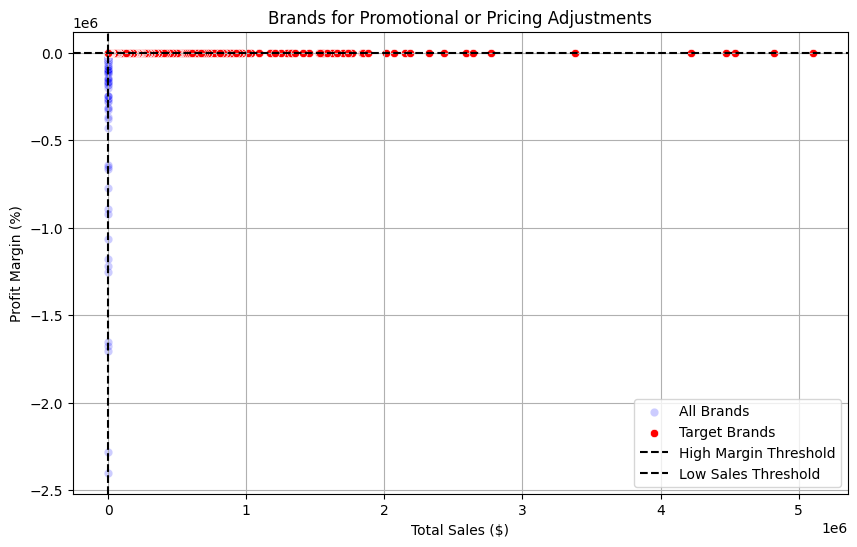

In [22]:
plt.figure(figsize=(10, 6))

# Scatter plot for all brands
sns.scatterplot(
    data=brand_performance,
    x='TotalSalesDollars',
    y='ProfitMargin',
    color='blue',
    label='All Brands',
    alpha=0.2
)

# Scatter plot for target brands
sns.scatterplot(
    data=target_brands,
    x='TotalSalesDollars',
    y='ProfitMargin',
    color='red',
    label='Target Brands'
)

# Threshold lines
plt.axhline(high_margin_threshold, linestyle='--', color='black', label='High Margin Threshold')
plt.axvline(low_sales_threshold, linestyle='--', color='black', label='Low Sales Threshold')

# Labels and title
plt.xlabel("Total Sales ($)")
plt.ylabel("Profit Margin (%)")
plt.title("Brands for Promotional or Pricing Adjustments")

# Legend and grid
plt.legend()
plt.grid(True)

# Show plot
plt.show()


which vendors and brands demaonstrate the highest sales performance

In [23]:
def format_dollars(value):
    if value >= 1_000_000:
        return f"{value / 1_000_000:.2f}M"
    elif value >= 1_000:
        return f"{value / 1_000:.2f}K"
    else:
        return str(value)


In [24]:
top_vendors = df.groupby("VendorName")["TotalSalesDollars"].sum().nlargest(10)
top_brands = df.groupby("Description")["TotalSalesDollars"].sum().nlargest(10)

top_vendors


VendorName
DIAGEO NORTH AMERICA INC      68739834.97
MARTIGNETTI COMPANIES         40960117.82
PERNOD RICARD USA             32279544.17
JIM BEAM BRANDS COMPANY       31898621.16
BACARDI USA INC               25005365.79
CONSTELLATION BRANDS INC      24467134.23
E & J GALLO WINERY            18553774.66
BROWN-FORMAN CORP             18476611.60
ULTRA BEVERAGE COMPANY LLP    17802646.10
M S WALKER INC                15436066.26
Name: TotalSalesDollars, dtype: float64

In [25]:
top_brands

Description
Jack Daniels No 7 Black    7964746.76
Tito's Handmade Vodka      7399657.58
Grey Goose Vodka           7209608.06
Capt Morgan Spiced Rum     6356320.62
Absolut 80 Proof           6244752.03
Jameson Irish Whiskey      5715759.69
Ketel One Vodka            5070083.56
Baileys Irish Cream        4150122.07
Kahlua                     3604858.66
Tanqueray                  3456697.90
Name: TotalSalesDollars, dtype: float64

               Description TotalSalesDollars
0  Jack Daniels No 7 Black     $7,964,746.76
1    Tito's Handmade Vodka     $7,399,657.58
2         Grey Goose Vodka     $7,209,608.06
3   Capt Morgan Spiced Rum     $6,356,320.62
4         Absolut 80 Proof     $6,244,752.03
5    Jameson Irish Whiskey     $5,715,759.69
6          Ketel One Vodka     $5,070,083.56
7      Baileys Irish Cream     $4,150,122.07
8                   Kahlua     $3,604,858.66
9                Tanqueray     $3,456,697.90


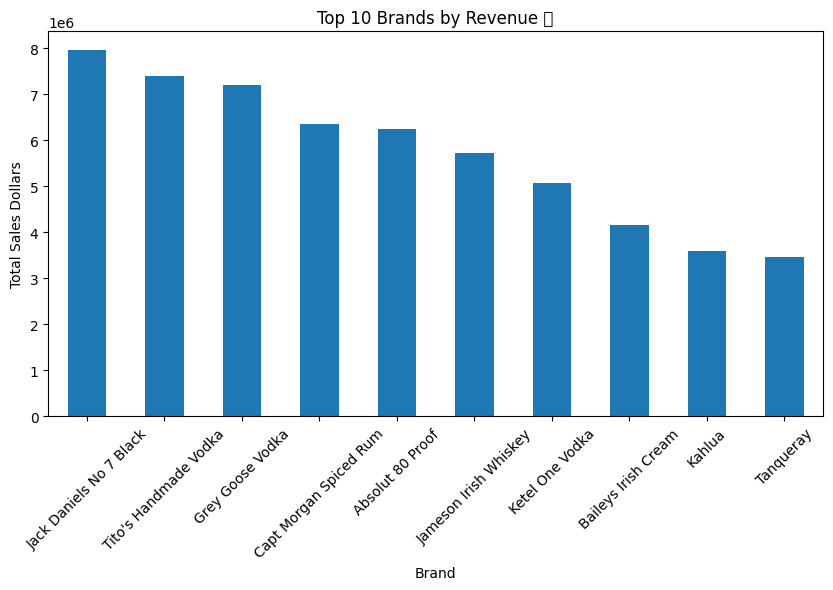

In [26]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

# 🔹 Step 1: Connect to database
conn = sqlite3.connect("inventory.db")

# 🔹 Step 2: Load data
df = pd.read_sql("SELECT * FROM vendor_sales_summary", conn)

# 🔹 Step 3: Get Top 10 Brands
top_brands = df.groupby("Description")["TotalSalesDollars"].sum().nlargest(10).reset_index()

# 🔹 Step 4: Format function
def format_dollars(x):
    return f"${x:,.2f}"

# 🔹 Step 5: Apply formatting
top_brands["TotalSalesDollars"] = top_brands["TotalSalesDollars"].apply(format_dollars)

# 🔹 Step 6: Print result
print(top_brands)

# 🔹 Step 7: (Optional) Plot chart
# Convert back to numeric for plotting
df_plot = df.groupby("Description")["TotalSalesDollars"].sum().nlargest(10)

df_plot.plot(kind='bar', figsize=(10,5))
plt.title("Top 10 Brands by Revenue 💰")
plt.xlabel("Brand")
plt.ylabel("Total Sales Dollars")
plt.xticks(rotation=45)
plt.show()

# 🔹 Step 8: Close connection
conn.close()

ValueError: Per-column arrays must each be 1-dimensional

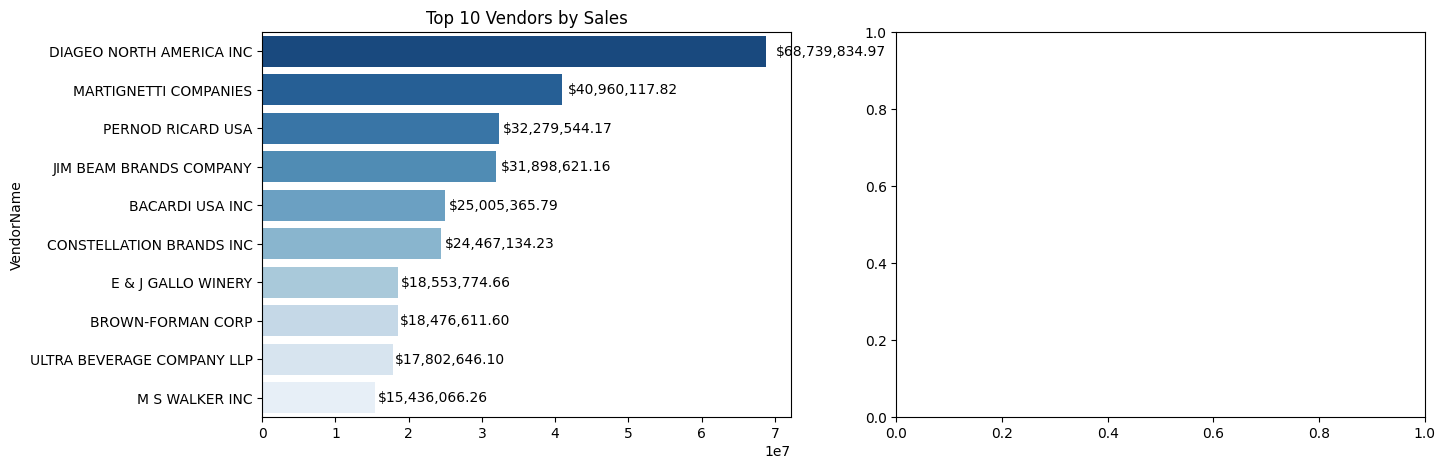

In [27]:
plt.figure(figsize=(15, 5))

# Plot for Top Vendors
ax1 = plt.subplot(1, 2, 1)
sns.barplot(
    x=top_vendors.values,          # numeric values
    y=top_vendors.index,           # category labels
    palette="Blues_r",
    ax=ax1
)
ax1.set_title("Top 10 Vendors by Sales")

# Annotate bars with formatted dollar values
for bar in ax1.patches:
    ax1.text(
        bar.get_width() + (bar.get_width() * 0.02),
        bar.get_y() + bar.get_height() / 2,
        format_dollars(bar.get_width()),
        ha='left', va='center', fontsize=10, color='black'
    )

# Plot for Top Brands
ax2 = plt.subplot(1, 2, 2)
sns.barplot(
    x=top_brands.values,           # numeric values
    y=top_brands.index.astype(str),# category labels
    palette="Reds_r",
    ax=ax2
)
ax2.set_title("Top 10 Brands by Sales")

# Annotate bars with formatted dollar values
for bar in ax2.patches:
    ax2.text(
        bar.get_width() + (bar.get_width() * 0.02),
        bar.get_y() + bar.get_height() / 2,
        format_dollars(bar.get_width()),
        ha='left', va='center', fontsize=10, color='black'
    )

plt.tight_layout()
plt.show()


which vendor constribute the most to total purchase dollars?

In [29]:
df.groupby('VendorName').agg({
    'TotalPurchaseDollars': 'sum',
    'GrossProfit': 'sum',
    'TotalSalesDollars': 'sum'
})


,TotalPurchaseDollars,GrossProfit,TotalSalesDollars
VendorName,,,
AAPER ALCOHOL & CHEMICAL CO,105.07,-105.07,0.00
ADAMBA IMPORTS INTL INC,76770.25,-9194.03,67576.22
ALISA CARR BEVERAGES,34951.68,78638.50,113590.18
ALTAMAR BRANDS LLC,11706.20,4000.61,15706.81
AMERICAN SPIRITS EXCHANGE,1205.16,514.81,1719.97
...,...,...,...
WEIN BAUER INC,43517.00,13413.23,56930.23
WESTERN SPIRITS BEVERAGE CO,361249.21,81820.99,443070.20
WILLIAM GRANT & SONS INC,5960744.35,1674483.96,7635228.31


In [31]:
vendor_performance = df.copy()

In [32]:
vendor_performance['PurchaseContribution%'] = (
    vendor_performance['TotalPurchaseDollars'] /
    vendor_performance['TotalPurchaseDollars'].sum()
) * 100

In [33]:
# Create dataframe
vendor_performance = df.copy()

# Calculate contribution %
vendor_performance['PurchaseContribution%'] = (
    vendor_performance['TotalPurchaseDollars'] /
    vendor_performance['TotalPurchaseDollars'].sum()
) * 100

print(vendor_performance.head())

   VendorNumber                VendorName  Brand              Description  \
0          1128         BROWN-FORMAN CORP   1233  Jack Daniels No 7 Black   
1          4425     MARTIGNETTI COMPANIES   3405    Tito's Handmade Vodka   
2         17035         PERNOD RICARD USA   8068         Absolut 80 Proof   
3          3960  DIAGEO NORTH AMERICA INC   4261   Capt Morgan Spiced Rum   
4          3960  DIAGEO NORTH AMERICA INC   3545          Ketel One Vodka   

   PurchasePrice  ActualPrice  Volume  TotalPurchaseQuantity  \
0          26.27        36.99  1750.0                 145080   
1          23.19        28.99  1750.0                 164038   
2          18.24        24.99  1750.0                 187407   
3          16.17        22.99  1750.0                 201682   
4          21.89        29.99  1750.0                 138109   

   TotalPurchaseDollars  TotalSalesQuantity  TotalSalesDollars  \
0            3811251.60            142049.0         5101919.51   
1            3804041

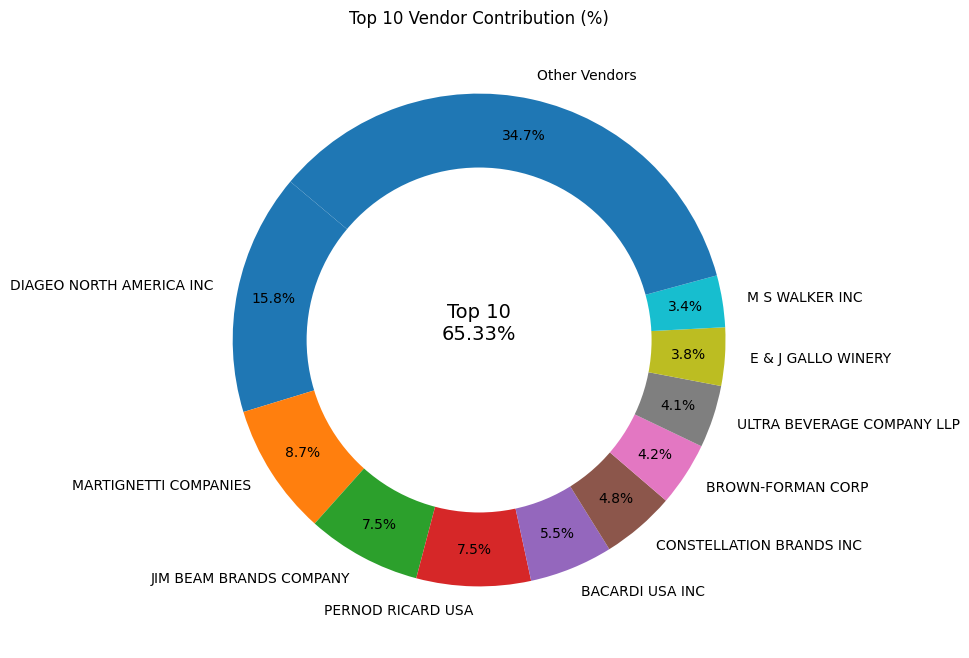

In [45]:
import matplotlib.pyplot as plt

# Step 1: Create top vendors properly
top_vendors = df.groupby("VendorName")["TotalPurchaseDollars"].sum().nlargest(10).reset_index()

# Step 2: Contribution %
total_purchase = df["TotalPurchaseDollars"].sum()

top_vendors['PurchaseContribution%'] = (
    top_vendors['TotalPurchaseDollars'] / total_purchase
) * 100

# Step 3: Prepare data
vendors = list(top_vendors['VendorName'])
purchase_contributions = list(top_vendors['PurchaseContribution%'])

# Step 4: Add "Other Vendors"
total_contribution = sum(purchase_contributions)
vendors.append("Other Vendors")
purchase_contributions.append(100 - total_contribution)

# Step 5: Donut chart
fig, ax = plt.subplots(figsize=(8, 8))

ax.pie(
    purchase_contributions,
    labels=vendors,
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=0.85
)

# Donut hole
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig.gca().add_artist(centre_circle)

# Center text
plt.text(0, 0, f"Top 10\n{total_contribution:.2f}%", ha='center', fontsize=14)

plt.title("Top 10 Vendor Contribution (%)")
plt.show()

does purchasing in bulk reduce unit price,and what is the  optimal purchase volume for cost saving?

In [46]:
df['UnitPurchasePrice'] = df['TotalPurchaseDollars'] / df['TotalPurchaseQuantity']


In [49]:
df["OrderSize"] = pd.qcut(
    df["TotalPurchaseQuantity"],
    q=3,
    labels=["Small", "Medium", "Large"]
)

In [54]:
df[['OrderSize','TotalPurchaseQuantity']]

,OrderSize,TotalPurchaseQuantity
0,Large,145080
1,Large,164038
2,Large,187407
3,Large,201682
4,Large,138109
...,...,...
10687,Small,2
10688,Small,6
10689,Small,2
10690,Small,1


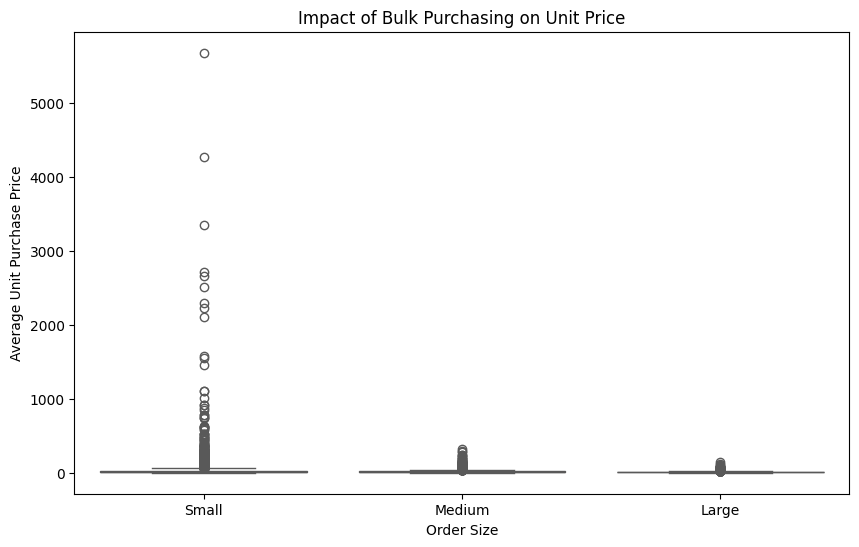

In [55]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="OrderSize", y="UnitPurchasePrice", palette="Set2")
plt.title("Impact of Bulk Purchasing on Unit Price")
plt.xlabel("Order Size")
plt.ylabel("Average Unit Purchase Price")
plt.show()
